In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Would magnitude error correspond to bright companions?

In [138]:
everything_table = Table.read("../BigData/ALL_gaia_source_and_xp_within_200pc.hdf5", path="table")

In [139]:
pc0 = everything_table[everything_table["predicted_class"] == 0]
lowm0 = pc0[pc0["mass_single"] < 0.4] 

In [140]:
pc1 = everything_table[everything_table["predicted_class"] == 1]
lowm1 = pc1[pc1["m2_binary"] < 0.4] 

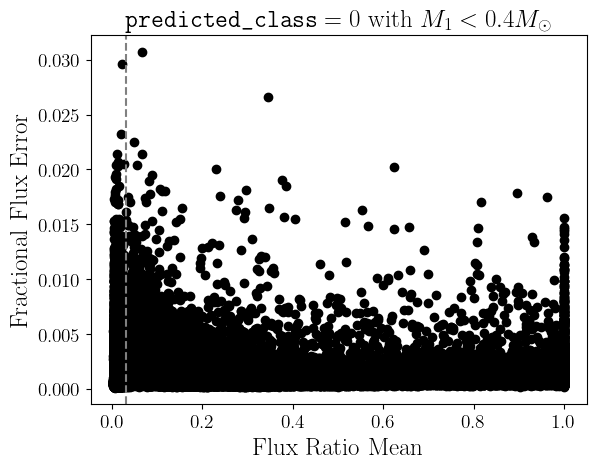

In [27]:
plt.scatter(lowm0["flux_ratio_mean"], 1/lowm0["phot_g_mean_flux_over_error"]);
plt.axvline(x=10**-1.5, color="grey", ls="--");
plt.xlabel("Flux Ratio Mean");
plt.ylabel("Fractional Flux Error");
plt.title(r"$\texttt{predicted\_class}=0$ with $M_1 < 0.4 M_\odot$");

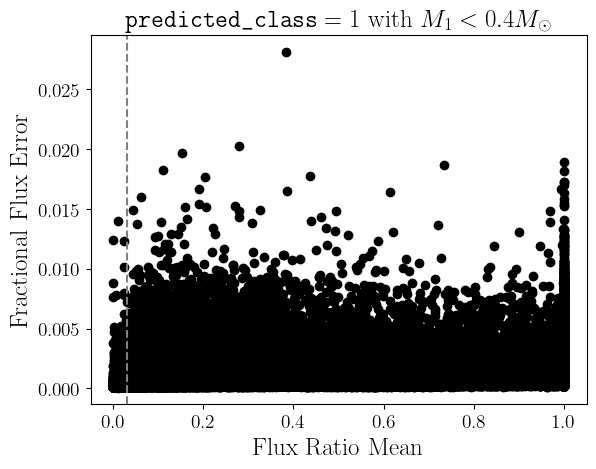

In [28]:
plt.scatter(lowm1["flux_ratio_mean"], 1/lowm1["phot_g_mean_flux_over_error"]);
plt.axvline(x=10**-1.5, color="grey", ls="--");
plt.xlabel("Flux Ratio Mean");
plt.ylabel("Fractional Flux Error");
plt.title(r"$\texttt{predicted\_class}=1$ with $M_1 < 0.4 M_\odot$");

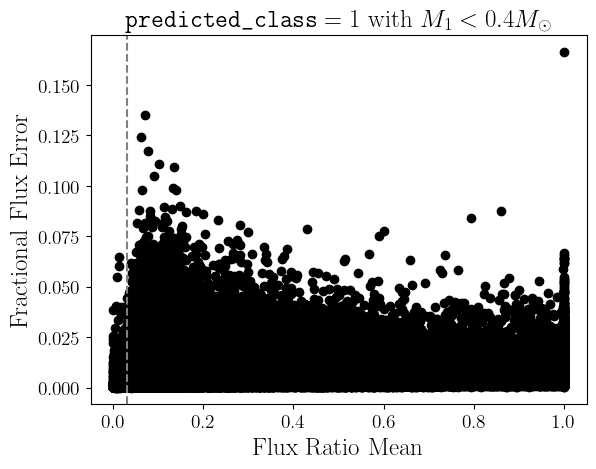

In [142]:
plt.scatter(lowm1["flux_ratio_mean"], 1/lowm1["phot_bp_mean_flux_over_error"]);
plt.axvline(x=10**-1.5, color="grey", ls="--");
plt.xlabel("Flux Ratio Mean");
plt.ylabel("Fractional Flux Error");
plt.title(r"$\texttt{predicted\_class}=1$ with $M_1 < 0.4 M_\odot$");

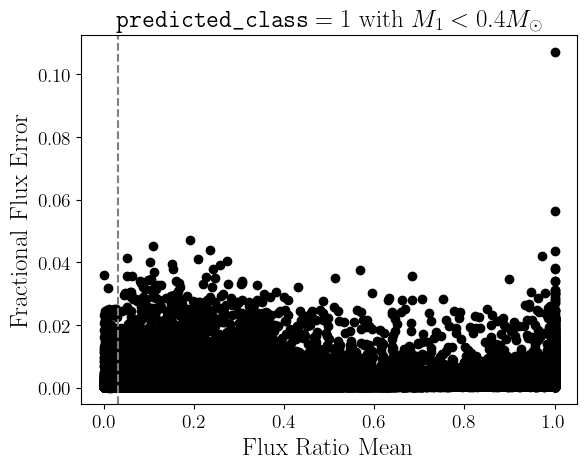

In [143]:
plt.scatter(lowm1["flux_ratio_mean"], 1/lowm1["phot_rp_mean_flux_over_error"]);
plt.axvline(x=10**-1.5, color="grey", ls="--");
plt.xlabel("Flux Ratio Mean");
plt.ylabel("Fractional Flux Error");
plt.title(r"$\texttt{predicted\_class}=1$ with $M_1 < 0.4 M_\odot$");

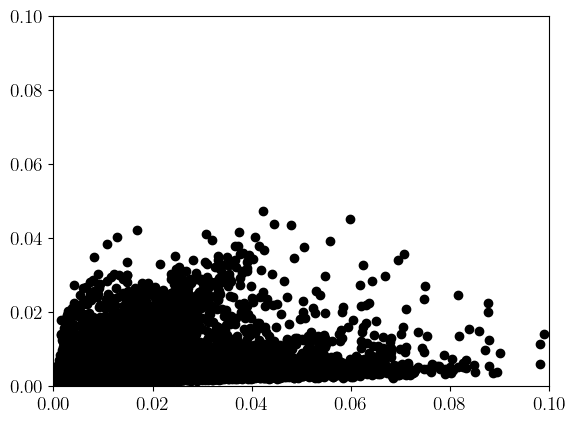

In [145]:
plt.scatter(1/lowm1["phot_bp_mean_flux_over_error"], 1/lowm1["phot_rp_mean_flux_over_error"]);
plt.xlim([0,0.1]);
plt.ylim([0,0.1]);

## G-uncertainty and $\lambda$??

In [2]:
asp_import("GaiamockWrapper", "gw")

<module 'GaiamockWrapper' from '/home/bepennell/research/AstrometricSignalProcessing/GaiamockWrapper/GaiamockWrapper.py'>

In [131]:
obj = {
    "ra": 25,
    "dec": 25,
    "pmra": 0,
    "pmdec": 0,
    "parallax": 10,
    "m1": 0.4,
    "m2": 0.1,
    "phot_g_mean_mag": 14,
    "f": 0.03,
    "period": 800,
    "ecc": 0.3,
    "inc": np.pi/4,
    "w": np.pi/3,
    "omega": np.pi/6,
    "Tp": 0
}

obj["q"] = obj["m2"] / obj["m1"]

In [132]:
c_funcs = gw.generate_cfuncs()
t, t_mod = gw.generate_scanning_times(obj["ra"], obj["dec"])

In [26]:
COUNTS = 5
gs = np.linspace(10,20,100)
ruwes = np.zeros_like(gs)
for i, g in enumerate(tqdm(gs)):
    obj["phot_g_mean_mag"] = g
    truwes = np.array([gw.rapid_solution_type_wrapper(obj, t, t_mod, c_funcs, skip_full=True, return_ruwe=True)[1] for _ in range(COUNTS)])
    ruwes[i] = np.mean(truwes)

  0%|          | 0/100 [00:00<?, ?it/s]

In [27]:
uncertainties = np.array([gw.gaiamock.al_uncertainty_per_ccd_interp(g) for g in gs])

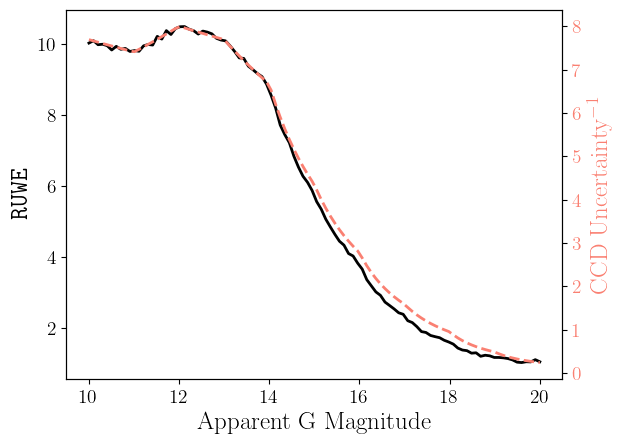

In [28]:
plt.plot(gs, ruwes, lw=2);
plt.xlabel("Apparent G Magnitude");
plt.ylabel(r"$\texttt{RUWE}$");
ax = plt.twinx()
plt.plot(gs, 1/uncertainties, color="salmon", lw=2, ls="--");
plt.ylabel(r"CCD Uncertainty$^{-1}$", color="salmon");
plt.yticks(color="salmon");

In [133]:
gs = np.linspace(10,20,100)
uncertainties = np.array([gw.gaiamock.al_uncertainty_per_ccd_interp(g) for g in gs])

def generate_ruwes(obj, gs, t, t_mod, c_funcs, counts=5):
    ruwes = np.zeros_like(gs)
    for i, g in enumerate(tqdm(gs)):
        obj["phot_g_mean_mag"] = g
        truwes = np.array([gw.rapid_solution_type_wrapper(obj, t, t_mod, c_funcs, skip_full=True, return_ruwe=True)[1] for _ in range(counts)])
        ruwes[i] = np.mean(truwes)
    return ruwes

def comparison_plot(gs, ruwes, uncertainties):
    plt.plot(gs, ruwes, lw=2);
    plt.xlabel("Apparent G Magnitude");
    plt.ylabel(r"$\texttt{RUWE}$");
    ax = plt.twinx()
    plt.plot(gs, 1/uncertainties, color="salmon", lw=2, ls="--");
    plt.ylabel(r"CCD Uncertainty$^{-1}$", color="salmon");
    plt.yticks(color="salmon"); 

def generate_and_plot(obj, gs, t, t_mod, c_funcs, counts=5):
    ruwes = generate_ruwes(obj, gs, t, t_mod, c_funcs, counts)
    uncertainties = np.array([gw.gaiamock.al_uncertainty_per_ccd_interp(g) for g in gs])
    comparison_plot(gs, ruwes, uncertainties)

  0%|          | 0/100 [00:00<?, ?it/s]

{'ra': 25, 'dec': 25, 'pmra': 0, 'pmdec': 0, 'parallax': 10, 'm1': 0.2, 'm2': 0.1, 'phot_g_mean_mag': np.float64(20.0), 'f': 0.03, 'period': 800, 'ecc': 0.3, 'inc': 0.7853981633974483, 'w': 1.0471975511965976, 'omega': 0.5235987755982988, 'Tp': 0, 'q': 0.25}


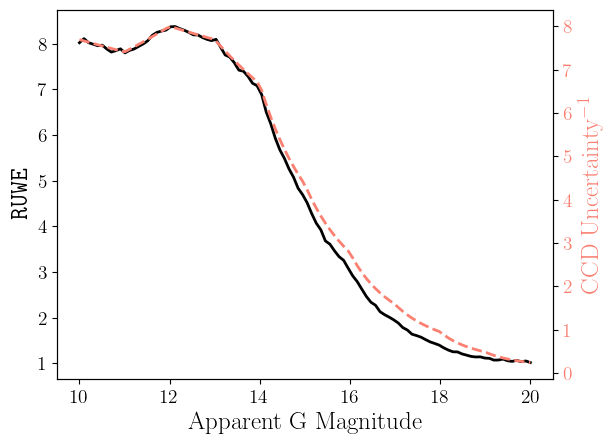

In [134]:
obj2 = obj.copy()
obj2["m1"] = 0.2
generate_and_plot(obj2, gs, t, t_mod, c_funcs, counts=10)
print(obj2)

  0%|          | 0/100 [00:00<?, ?it/s]

{'ra': 25, 'dec': 25, 'pmra': 0, 'pmdec': 0, 'parallax': 3, 'm1': 0.2, 'm2': 0.1, 'phot_g_mean_mag': np.float64(20.0), 'f': 0.03, 'period': 800, 'ecc': 0.3, 'inc': 0.7853981633974483, 'w': 1.0471975511965976, 'omega': 0.5235987755982988, 'Tp': 0, 'q': 0.25}


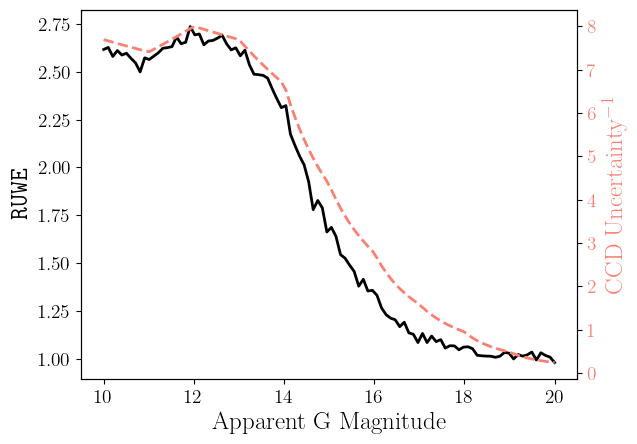

In [135]:
obj2 = obj.copy()
obj2["m1"] = 0.2
obj2["parallax"] = 3
generate_and_plot(obj2, gs, t, t_mod, c_funcs, counts=10)
print(obj2)

  0%|          | 0/100 [00:00<?, ?it/s]

{'ra': 25, 'dec': 25, 'pmra': 0, 'pmdec': 0, 'parallax': 3, 'm1': 0.4, 'm2': 0.1, 'phot_g_mean_mag': np.float64(20.0), 'f': 0.03, 'period': 100, 'ecc': 0.3, 'inc': 0.7853981633974483, 'w': 1.0471975511965976, 'omega': 0.5235987755982988, 'Tp': 0, 'q': 0.25}


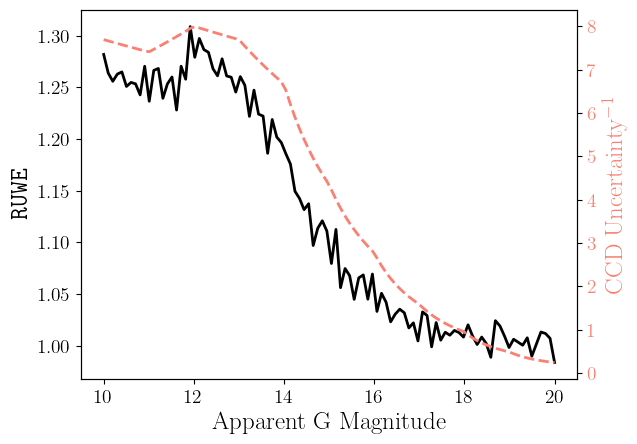

In [31]:
obj2 = obj.copy()
obj2["period"] = 100
obj2["parallax"] = 3
generate_and_plot(obj2, gs, t, t_mod, c_funcs, counts=25)
print(obj2)

## Folding G into $\lambda$ now

In [213]:
asp_import("GaiamockWrapper", "gw")

<module 'GaiamockWrapper' from '/home/bepennell/research/AstrometricSignalProcessing/GaiamockWrapper/GaiamockWrapper.py'>

In [3]:
obj = {
    "ra": 25,
    "dec": 25,
    "pmra": 0,
    "pmdec": 0,
    "parallax": 4,
    "m1": 0.4,
    "m2": 0.15,
    "phot_g_mean_mag": 14,
    "f": 0.03,
    "period": 900,
    "ecc": 0.3,
    "inc": np.pi/4,
    "w": np.pi/3,
    "omega": np.pi/6,
    "Tp": 0
}

obj["q"] = obj["m2"] / obj["m1"]

In [4]:
c_funcs = gw.generate_cfuncs()
t, t_mod = gw.generate_scanning_times(obj["ra"], obj["dec"])

gs = np.linspace(10,20,1000)
uncertainties = np.array([gw.gaiamock.al_uncertainty_per_ccd_interp(g) for g in gs])

In [6]:
COUNTS = 50
reference_parallax = 4
obj["parallax"] = reference_parallax
plxs = np.linspace(reference_parallax,20,100)
ruwes = np.zeros_like(plxs)
reference_uncertainty = gw.gaiamock.al_uncertainty_per_ccd_interp(obj["phot_g_mean_mag"])
new_mags = np.zeros_like(plxs)

In [ ]:
for i, plx in enumerate(tqdm(plxs)):
    obj["parallax"] = plx
    plx_ratio = reference_parallax / plx
    obj["phot_g_mean_mag"] = np.interp(reference_uncertainty/plx_ratio, uncertainties, gs)
    new_mags[i] = obj["phot_g_mean_mag"]
    truwes = np.array([gw.rapid_solution_type_wrapper(obj, t, t_mod, c_funcs, skip_full=True, return_ruwe=True)[1] for _ in range(COUNTS)])
    ruwes[i] = np.median(truwes)

  0%|          | 0/100 [00:00<?, ?it/s]

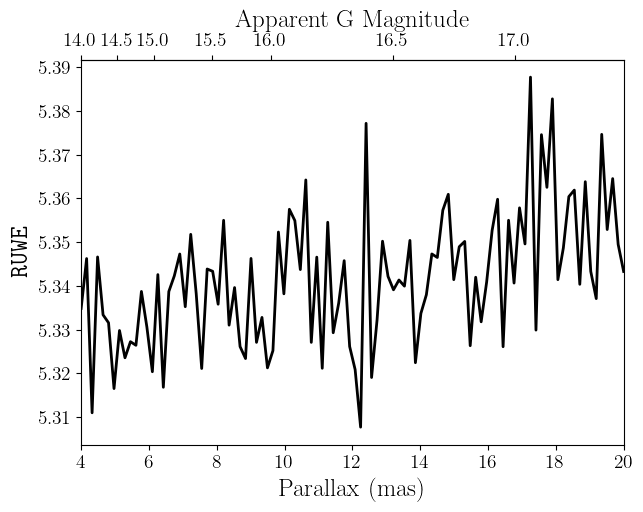

In [345]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(plxs, ruwes, lw=2);
ax.set_xlabel("Parallax (mas)");
ax.set_ylabel(r"$\texttt{RUWE}$");
ax.set_xlim([4,20]);

def parallax_to_mag_singular(plx):
    plx_ratio = reference_parallax / plx
    return np.interp(reference_uncertainty/plx_ratio, uncertainties, gs)

def mag_to_parallax_singular(mag):
    mag_ratio = reference_uncertainty / gw.gaiamock.al_uncertainty_per_ccd_interp(mag)
    return reference_parallax / mag_ratio

def parallax_to_mag(plx):
    if len(plx) > 1:
        return np.array([parallax_to_mag_singular(p) for p in plx])
    return parallax_to_mag_singular(plx)

def mag_to_parallax(mag):
    if len(mag) > 1:
        return np.array([mag_to_parallax_singular(m) for m in mag])
    return mag_to_parallax_singular(mag)

ax2 = ax.secondary_xaxis("top", functions=(parallax_to_mag, mag_to_parallax))
ax2.set_xlabel("Apparent G Magnitude");

In [7]:
ruwes_h = np.zeros_like(plxs)
for i, plx in enumerate(tqdm(plxs)):
    obj["m1"] = 0.3
    obj["q"] = 0.3
    obj["m2"] = obj["m1"] * obj["q"]
    obj["parallax"] = plx
    plx_ratio = reference_parallax / plx
    obj["phot_g_mean_mag"] = np.interp(reference_uncertainty/plx_ratio, uncertainties, gs)
    truwes = np.array([gw.rapid_solution_type_wrapper(obj, t, t_mod, c_funcs, skip_full=True, return_ruwe=True)[1] for _ in range(COUNTS)])
    ruwes_h[i] = np.median(truwes)

ruwes_l = np.zeros_like(plxs)
for i, plx in enumerate(tqdm(plxs)):
    obj["m1"] = 0.25
    obj["q"] = 0.3
    obj["m2"] = obj["m1"] * obj["q"]
    obj["parallax"] = plx
    plx_ratio = reference_parallax / plx
    obj["phot_g_mean_mag"] = np.interp(reference_uncertainty/plx_ratio, uncertainties, gs)
    truwes = np.array([gw.rapid_solution_type_wrapper(obj, t, t_mod, c_funcs, skip_full=True, return_ruwe=True)[1] for _ in range(COUNTS)])
    ruwes_l[i] = np.median(truwes)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

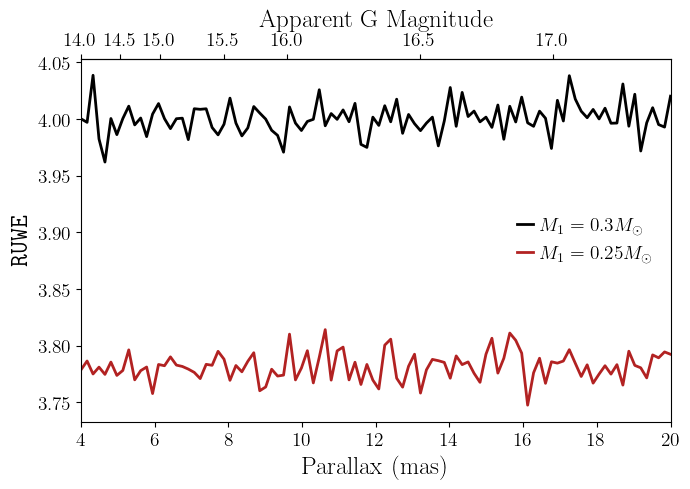

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(plxs, ruwes_h, lw=2, label=r"$M_1=0.3 M_\odot$");
ax.plot(plxs, ruwes_l, lw=2, label=r"$M_1=0.25 M_\odot$");

ax.set_xlabel("Parallax (mas)");
ax.set_ylabel(r"$\texttt{RUWE}$");
ax.set_xlim([4,20]);
ax.legend();

def parallax_to_mag_singular(plx):
    plx_ratio = reference_parallax / plx
    return np.interp(reference_uncertainty/plx_ratio, uncertainties, gs)

def mag_to_parallax_singular(mag):
    mag_ratio = reference_uncertainty / gw.gaiamock.al_uncertainty_per_ccd_interp(mag)
    return reference_parallax / mag_ratio

def parallax_to_mag(plx):
    if len(plx) > 1:
        return np.array([parallax_to_mag_singular(p) for p in plx])
    return parallax_to_mag_singular(plx)

def mag_to_parallax(mag):
    if len(mag) > 1:
        return np.array([mag_to_parallax_singular(m) for m in mag])
    return mag_to_parallax_singular(mag)

ax2 = ax.secondary_xaxis("top", functions=(parallax_to_mag, mag_to_parallax))
ax2.set_xlabel("Apparent G Magnitude");
plt.tight_layout()
plt.savefig("./plots/proof_of_lambda.pdf", transparent=True, dpi=800)

THE SCHEME WORKS !!

## Testing this with the grid

In [34]:
import Sampler

In [65]:
gs = np.linspace(10,20,1000)
uncertainties = np.array([gw.gaiamock.al_uncertainty_per_ccd_interp(g) for g in gs])

In [32]:
sc_cubes_big = pickle.load(open("./data/2026-04-03-65_mdwarfs.pkl", "rb"))
sc_cubes_small = pickle.load(open("./data/2026-04-03-50_mdwarfs.pkl", "rb"))

In [158]:
mdwarfs_0204 = Table.read('./data/0204_final_catalogue.fits', format='fits')
mlims = np.percentile(mdwarfs_0204["mass_single"], np.linspace(0,100,11))
gmedians_0204 = np.zeros_like(mlims[:-1])
gcents = np.zeros_like(mlims[:-1])
g_lists = []

bins = np.linspace(15,18,50)
for i in range(len(gmedians_0204)):
    tcat = mdwarfs_0204[(mdwarfs_0204["mass_single"] >= mlims[i]) & (mdwarfs_0204["mass_single"] < mlims[i+1])]
    gmedians_0204[i] = np.mean(tcat["phot_g_mean_mag"])
    g_lists.append(list(tcat["phot_g_mean_mag"]))
    vals, bins = np.histogram(tcat["phot_g_mean_mag"], bins=bins)
    gcents[i] = bins[np.argmax(vals)]

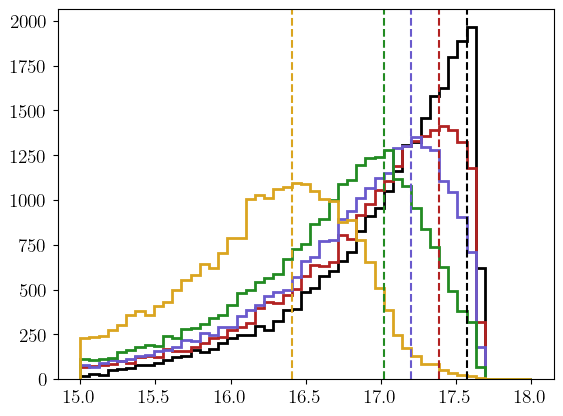

In [309]:
bins = np.linspace(15,18,50)
plt.hist(g_lists[0], bins=bins, histtype="step", lw=2);
plt.hist(g_lists[2], bins=bins, histtype="step", lw=2);
plt.hist(g_lists[3], bins=bins, histtype="step", lw=2);
plt.hist(g_lists[5], bins=bins, histtype="step", lw=2);
plt.hist(g_lists[9], bins=bins, histtype="step", lw=2, color="goldenrod");
plt.axvline(x=gcents[0], color="k", ls="--");
plt.axvline(x=gcents[2], color="firebrick", ls="--");
plt.axvline(x=gcents[3], color="slateblue", ls="--");
plt.axvline(x=gcents[5], color="forestgreen", ls="--");
plt.axvline(x=gcents[9], color="goldenrod", ls="--");

In [310]:
ct = mdwarfs_0204[2]
target_object = dict(mass=ct["mass_single"], parallax=ct["parallax"], soltype_index=2, phot_g_mean_mag=ct["phot_g_mean_mag"])
ref_mag_error = gw.gaiamock.al_uncertainty_per_ccd_interp(target_object["phot_g_mean_mag"])
q = 0.4

tlam = aap(target_object["mass"], q*target_object["mass"], target_object["parallax"])
print(tlam)

0.8186500539434223


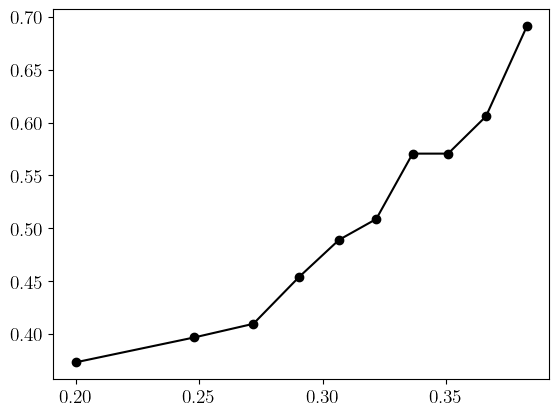

In [311]:
plt.plot(mlims[:-1], (ref_mag_error / gw.gaiamock.al_uncertainty_per_ccd_interp(gcents)), marker="o", label="Scaled Lambda");

In [313]:
def gscale(i):
    return 1 / (ref_mag_error / gw.gaiamock.al_uncertainty_per_ccd_interp(gcents[i]))

In [314]:
vals = np.zeros((10,3))
for i in range(10):
    newl = tlam * gscale(i)
    for j in range(3):
        lams = sc_cubes_small["meta"]["lambdas"][i][j]
        ldex = np.clip(np.searchsorted(sc_cubes_small["meta"]["lambdas"][0][0], newl), 0, sc_cubes_small["meta"]["lambdas"][0][0].size - 2)
        vals[i,j] = sc_cubes_small["hist"][i][j][:,ldex,2].sum()/250

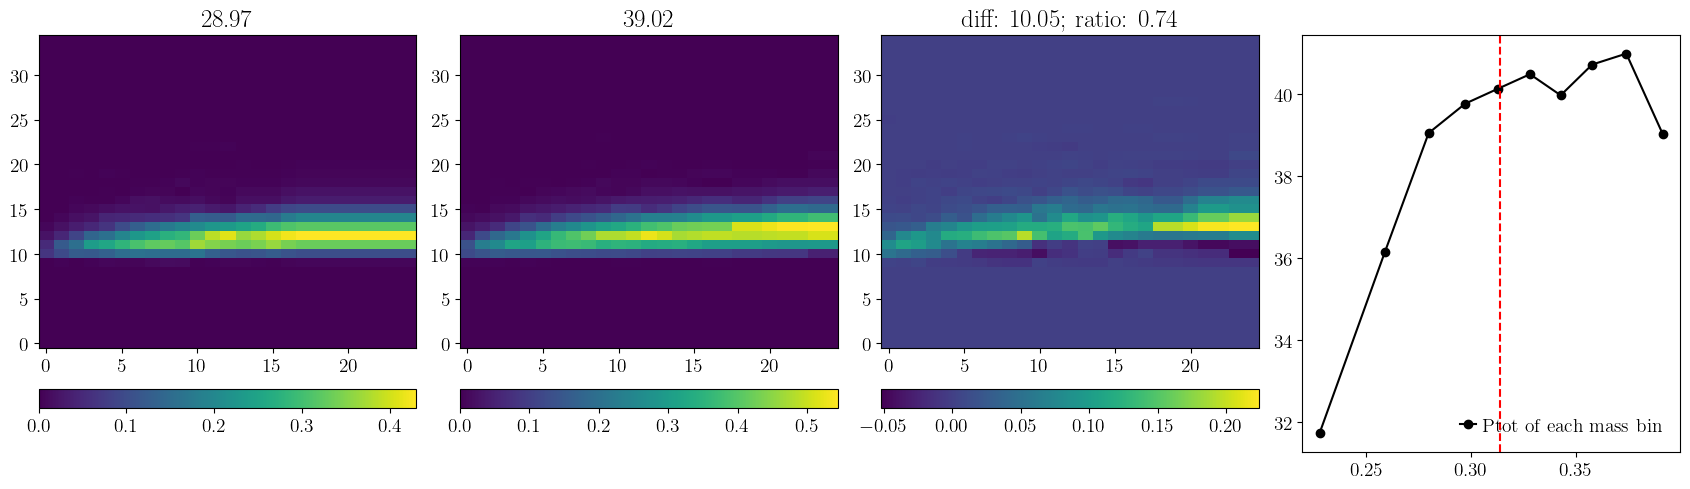

In [316]:
target_shape = (35,25)
p_range = (1,8)
q_range = (0.05, 0.5)
p_boundaries = np.linspace(*p_range, target_shape[0]+1)
q_boundaries = np.linspace(*q_range, target_shape[1]+1)

target_object["mass_index"] = 0
temp_object = target_object.copy()
temp_object["parallax"] = temp_object["parallax"] * gscale(3)
lm_grid_l = Sampler.compute_grid(temp_object, sc_cubes_small, p_boundaries, q_boundaries)

target_object["mass_index"] = 9
temp_object = target_object.copy()
temp_object["parallax"] = temp_object["parallax"] * gscale(9)
lm_grid_h = Sampler.compute_grid(temp_object, sc_cubes_small, p_boundaries, q_boundaries)

tots = []
for i in range(10):
    target_object["mass_index"] = i
    temp_object = target_object.copy()
    temp_object["parallax"] = temp_object["parallax"] * gscale(i)
    tots.append(Sampler.compute_grid(temp_object, sc_cubes_small, p_boundaries, q_boundaries).sum())

fig, axs = plt.subplots(1, 4, figsize=(17, 5))
im0 = axs[0].imshow(lm_grid_l, aspect="auto")
axs[0].set_title(f"{np.sum(lm_grid_l):.2f}")
axs[0].invert_yaxis()
im1 = axs[1].imshow(lm_grid_h, aspect="auto")
axs[1].set_title(f"{np.sum(lm_grid_h):.2f}")
axs[1].invert_yaxis()
im2 = axs[2].imshow(lm_grid_h-lm_grid_l, aspect="auto")
axs[2].set_title(f"diff: {np.sum(lm_grid_h-lm_grid_l):.2f}; ratio: {np.sum(lm_grid_l)/np.sum(lm_grid_h):.2f}")
axs[2].invert_yaxis()
fig.colorbar(im0, ax=axs[0], orientation="horizontal", pad=0.1)
fig.colorbar(im1, ax=axs[1], orientation="horizontal", pad=0.1)
fig.colorbar(im2, ax=axs[2], orientation="horizontal", pad=0.1)

axs[3].plot(sc_cubes_small["meta"]["mass_grid"], tots, marker="o", label="Ptot of each mass bin")
axs[3].axvline(x=target_object["mass"], **dline)
axs[3].legend();

# newax = axs[3].twinx()
# newax.plot(sc_cubes_small["meta"]["mass_grid"], np.sum(vals, axis=1), marker="o", color="grey", label="Ptot of Lambda column")
# newax.legend();

plt.tight_layout()